In [7]:
from get_vibration_data import get_vibration_data
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from fem_model import ContextUnet
from tqdm import tqdm
import json
from utils import draw_disp_on_mesh,draw_mesh,inverse_minmax_scale
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [8]:
sample_num=0
Lx=6
Ly=2
Lz=2
nx=16
ny=18
nz=10
xm0  = 0.9972
xm1= xm0+Lx/nx*2
ym0= 0.36
ym1 = ym0+Ly/ny*2
zm0= 0
zm1 = zm0+Lz/nz*2
E =6.9e10
nu = 0.33
rho = 2700
m_add=31
freq=262
a_base=15
zeta= 0.005



In [9]:
xyz,disp,df_cells,FRF=get_vibration_data(sample_num,Lx,Ly,Lz,nx,ny,nz,xm0,xm1,ym0,ym1,zm0,zm1,E,nu,rho,m_add,freq,a_base,zeta)

Number of converged eigenpairs 470
saved: nodal_stress_disp.csv
saved: edge_infos.csv
saved: params.txt


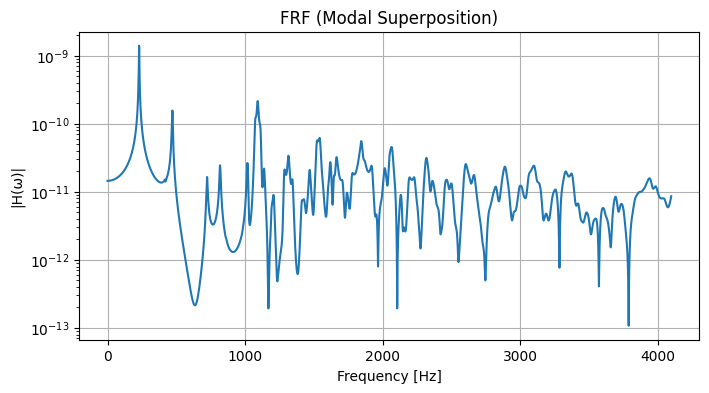

In [10]:
plt.figure(figsize=(8,4))
plt.semilogy(FRF[0], FRF[1])
plt.xlabel("Frequency [Hz]")
plt.ylabel("|H(ω)|")
plt.title("FRF (Modal Superposition)")
plt.grid(True)
plt.show()

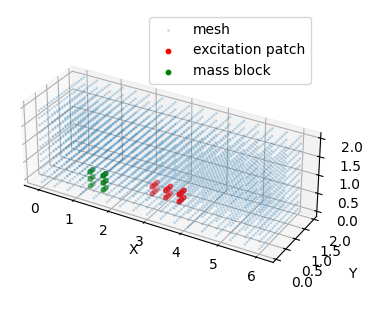

In [11]:
draw_mesh(xyz.values[:,0],xyz.values[:,1],xyz.values[:,2],Lx,Ly,Lz,nx,ny,nz,xm0,xm1,ym0,ym1,zm0,zm1)

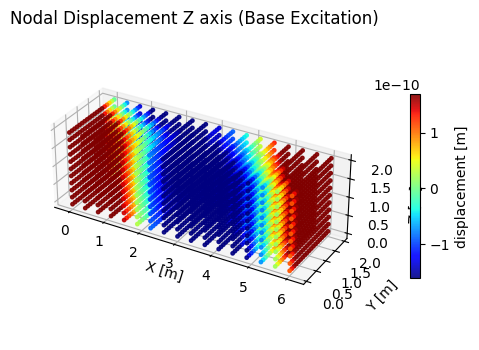

In [12]:
draw_disp_on_mesh(xyz.values[:,0],xyz.values[:,1],xyz.values[:,2],disp.values[:,2])

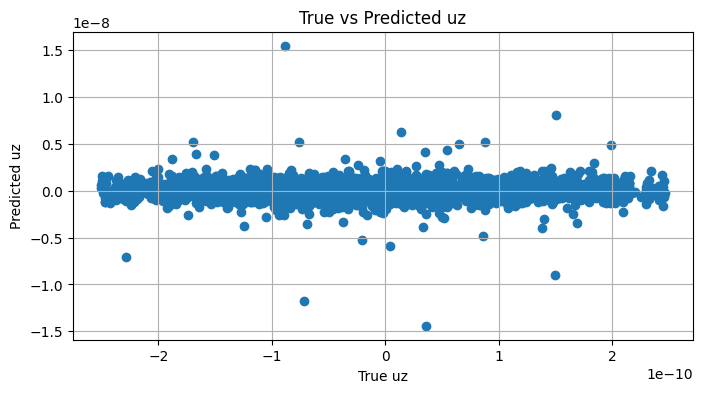

In [29]:
plt.figure(figsize=(8,4))
plt.scatter(disp[['ux']].values.reshape(-1),data[['uz']].values.reshape(-1))
plt.xlabel("True uz")
plt.ylabel("Predicted uz")
plt.title("True vs Predicted uz")
plt.grid(True)
plt.show()